# HydrAI — Baseline PyTorch NN (Inlet→Outlet)

**Purpose:** train and evaluate a multi-output PyTorch MLP surrogate from **inlet design** features to **exit-plane** state and species mass fractions. Same task shape as [Main_4_train_and_evaluate_tree_models_IO.ipynb](Main_4_train_and_evaluate_tree_models_IO.ipynb); training defaults are read from `configs/ml/ml_training_config.json`. An optional Optuna hyperparameter search is gated by a single flag (`IF_HYPERPARAM_TUNING`, Section 2 → Section 6b).

**Prerequisites:** run Main_2 and Main_3 so `data/processed/features_targets_*.pkl` exists.

---

## Baseline NN strategy

1. **Inlet design inputs only** — the network sees run-level features (temperature, pressure, geometry, mass flow, heat flux, and `reactant_type` if present). Axial coordinates (`z_position_m`, `relative_position`) are deliberately excluded.
2. **Exit-plane targets** — one row per simulation run at maximum `relative_position`, same extraction as Main_4.
3. **Standard MLP** — 3 hidden layers (default `128 → 64 → 32`) with ReLU and dropout, trained with `nn.MSELoss` and Adam on standardised targets (so Pa and mass fractions are comparable in the loss).
4. **Diagnostics** — train vs test convergence (MSE and R²), per-target metrics, parity and residual plots for the main state variables, and a per-target R² bar chart.

## Overfitting controls used here

- **Dropout** between hidden ReLUs (`nn.Dropout`, default `p=0.1`); active under `model.train()`, disabled under `model.eval()`.
- **Held-out test split** (`train_test_split`, default 20%) — never used for gradient updates.
- **Scalers fit on training data only**; the test split is only `transform`-ed.
- **Shuffled minibatches** (`DataLoader(..., shuffle=True)`) for stochastic optimisation.
- **Train vs test monitoring** at periodic checkpoints — a growing gap signals overfitting (first response: raise `dropout` or shrink hidden sizes in config).

*Deliberately not enabled here:* Adam `weight_decay`, learning-rate schedules, early stopping, k-fold CV, data augmentation.

## Optional hyperparameter tuning (Section 6b)

Setting `IF_HYPERPARAM_TUNING = True` runs an Optuna [TPE](https://optuna.readthedocs.io) study over `h1, h2, h3, dropout, learning_rate, batch_size`. The search uses a validation fold carved from the training split (test set stays held out), a median pruner to stop weak trials early, and validation R² (uniform average across all targets, physical units) as the objective. The best trial's hyperparameters then refit the production model, and the rest of the notebook (training, evaluation, plots, export) runs unchanged. Trial count, search budget, and timeout live under `neural_network.tuning` in the JSON config.

---

**Sections:**
1. Setup & imports
2. Paths & flags
3. Load config & data
4. Features & targets (exit-plane; inlet design inputs only)
5. Train/test split & scaling
6. PyTorch multi-output regression MLP
6b. Optional Optuna hyperparameter tuning (gated by `IF_HYPERPARAM_TUNING`)
6c. Architecture visualisation (matplotlib diagram, TikZ source, torchinfo summary)
7. Tensors & data loaders
8. Training loop & convergence (train + test MSE and R² vs epoch)
9. Test-set evaluation
10. Actual vs Predicted scatter (state variables)
10b. Residuals vs Actual (state variables)
10c. Per-target R² bar chart
11. Export model artifacts

In [1]:
# ════════════════════════════════════════════════════════════════════════════
# 1. SETUP & IMPORTS
# ════════════════════════════════════════════════════════════════════════════
import os
import sys
import glob
import json
import joblib
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Project root
current_dir = Path(os.getcwd())
project_root = current_dir if (current_dir / "src").exists() else current_dir.parent
sys.path.insert(0, str(project_root))
os.chdir(project_root)

from src.utils.plot_style import setup_matplotlib
from src.utils.run_log import start_run_log
from src.ml.dataframe_pickle import load_portable_pickle

setup_matplotlib()
start_run_log('Main_6__train_evaluate_SimpleNN_IO')
print("Libraries imported successfully.")

[run_log] outputs\reports\Main_6__train_evaluate_SimpleNN_IO.txt (overwrite)
Libraries imported successfully.


PyTorch version: 2.11.0+cpu
Using device:    cpu
Plot: True  |  Export figs: True  |  Export model: True
Main_6 is a defaults-only PyTorch MLP baseline (inlet -> outlet, no tuning).
Split:    test_size=0.2, random_state=42
NN arch:  h1=128, h2=64, h3=32, dropout=0.1
NN train: epochs=200, batch_size=256, lr=0.001
Tuning:   enabled=True, n_trials=30, epochs/trial=50, val_fraction=0.2

Data: features_targets_training_data_complete_20260507_095243.pkl
  Features: 9,208,918 rows × 8 cols
  Targets:  9,208,918 rows × 22 cols
Exit-plane dataset: 45,932 runs
  Inlet inputs   (6): ['initial_temperature_K', 'initial_pressure_Pa', 'reactor_length_m', 'reactor_diameter_m', 'mass_flow_rate_kgps', 'heat_flux_Wm2']
  State targets  (9): ['temperature_K', 'pressure_Pa', 'velocity_ms', 'density_kgm3', 'mean_molecular_weight_kgkmol', 'heat_capacity_cp_JkgK', 'heat_capacity_cv_JkgK', 'enthalpy_Jkg', 'thermal_conductivity_WmK']
  Species/lump   : 9 columns
  Total targets  : 18
Train: 36,745 (80%)  |  Tes

In [2]:
# ════════════════════════════════════════════════════════════════════════════
# 1b. DEVICE (CPU / NVIDIA CUDA / Apple MPS)
# ════════════════════════════════════════════════════════════════════════════
def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

device = get_device()
print(f"PyTorch version: {torch.__version__}")
print(f"Using device:    {device}")
if device.type == "cuda":
    print(f"GPU name:        {torch.cuda.get_device_name(0)}")

In [3]:
# ════════════════════════════════════════════════════════════════════════════
# 2. PATHS & FLAGS
# ════════════════════════════════════════════════════════════════════════════

# I/O flags
IF_PLOT_SHOWN          = True
IF_PLOT_EXPORT         = True
IF_MODEL_EXPORT        = True

# Optional hyperparameter tuning (Section 6c). Off by default — Main_6 is a
# defaults-only baseline. Setting True runs an Optuna TPE search over h1/h2/h3,
# dropout, learning_rate, and batch_size, refits the final model with the best
# hyperparameters, and the rest of the notebook runs as usual on the tuned net.
IF_HYPERPARAM_TUNING   = True

# Architecture-visualisation flags (Section 6b). Both diagram styles can be
# toggled independently; the torchinfo summary requires `pip install torchinfo`
# and gracefully degrades to a plain `print(model)` if it is not installed.
IF_ARCH_DIAGRAM_MPL  = True   # matplotlib circles+lines diagram (themed by setup_matplotlib)
IF_ARCH_DIAGRAM_TIKZ = True   # write a standalone TikZ .tex file (compile externally with pdflatex)
IF_ARCH_SUMMARY      = True   # textual layer-by-layer summary via torchinfo

# Paths
CONFIG_PATH        = project_root / "configs" / "ml" / "ml_training_config.json"
PROCESSED_DATA_DIR = project_root / "data" / "processed"
EXPORT_DIR         = project_root / "models"
FIG_DIR            = project_root / "outputs" / "figures" / "Main_6__train_evaluate_SimpleNN_IO"

print(f"Plot: {IF_PLOT_SHOWN}  |  Export figs: {IF_PLOT_EXPORT}  |  Export model: {IF_MODEL_EXPORT}")
print("Main_6 is a defaults-only PyTorch MLP baseline (inlet -> outlet, no tuning).")

In [4]:
# ════════════════════════════════════════════════════════════════════════════
# 3. LOAD CONFIG & DATA
# ════════════════════════════════════════════════════════════════════════════

# ── When this notebook actually uses ml_training_config.json ─────────────────
# This cell is the *only* place the JSON file is consulted; nothing else in
# Main_6 re-reads it. It runs on Kernel > Run All, or whenever you re-execute
# this single cell. Keys consumed by Main_6:
#   - top level:        test_size, random_state
#   - neural_network.*: epochs, batch_size, learning_rate, h1, h2, h3, dropout
# If the file is missing, or a key is omitted, the `config.get(..., default)`
# calls below fall back to the inline defaults shown as the second argument.
# Other keys in the JSON (random_forest, xgboost, ...) belong to Main_4/Main_5
# and are ignored here.
# Edit ml_training_config.json and re-run this cell to change behaviour;
# no kernel restart needed.

if CONFIG_PATH.exists():
    with open(CONFIG_PATH) as f:
        config = json.load(f)
else:
    config = {}
    print(f"[WARN] Config not found: {CONFIG_PATH}. Using defaults.")

TEST_SIZE    = config.get("test_size", 0.2)
RANDOM_STATE = config.get("random_state", 42)

NN_CONFIG     = config.get("neural_network", {})
EPOCHS        = int(NN_CONFIG.get("epochs", 200))
BATCH_SIZE    = int(NN_CONFIG.get("batch_size", 256))
LEARNING_RATE = float(NN_CONFIG.get("learning_rate", 1e-3))
H1            = int(NN_CONFIG.get("h1", 128))
H2            = int(NN_CONFIG.get("h2", 64))
H3            = int(NN_CONFIG.get("h3", 32))
DROPOUT       = float(NN_CONFIG.get("dropout", 0.1))

# Optuna search controls (consumed in Section 6c only when IF_HYPERPARAM_TUNING=True).
TUNING_CONFIG    = NN_CONFIG.get("tuning", {})
N_TRIALS         = int(TUNING_CONFIG.get("n_trials", 30))
EPOCHS_PER_TRIAL = int(TUNING_CONFIG.get("epochs_per_trial", max(20, EPOCHS // 4)))
VAL_FRACTION     = float(TUNING_CONFIG.get("validation_fraction", 0.2))
TUNING_TIMEOUT_S = TUNING_CONFIG.get("timeout_seconds", None)

print(f"Split:    test_size={TEST_SIZE}, random_state={RANDOM_STATE}")
print(f"NN arch:  h1={H1}, h2={H2}, h3={H3}, dropout={DROPOUT}")
print(f"NN train: epochs={EPOCHS}, batch_size={BATCH_SIZE}, lr={LEARNING_RATE}")
print(f"Tuning:   enabled={IF_HYPERPARAM_TUNING}, n_trials={N_TRIALS}, "
      f"epochs/trial={EPOCHS_PER_TRIAL}, val_fraction={VAL_FRACTION}")

# Data (latest features_targets_*.pkl)
pkl_files = sorted(glob.glob(str(PROCESSED_DATA_DIR / "features_targets_*.pkl")), reverse=True)
if not pkl_files:
    raise FileNotFoundError(f"No features_targets_*.pkl in {PROCESSED_DATA_DIR}. Run Main_3 first.")

DATA_FILE = pkl_files[0]
loaded = load_portable_pickle(DATA_FILE)
df_features = loaded["df_features"]
df_target   = loaded["df_target"]

print(f"\nData: {Path(DATA_FILE).name}")
print(f"  Features: {df_features.shape[0]:,} rows × {df_features.shape[1]} cols")
print(f"  Targets:  {df_target.shape[0]:,} rows × {df_target.shape[1]} cols")

In [5]:
# ════════════════════════════════════════════════════════════════════════════
# 4. FEATURES & TARGETS  (EXIT-PLANE; INLET DESIGN INPUTS ONLY)
# ════════════════════════════════════════════════════════════════════════════
# Inputs: inlet/run design columns only (no axial z, no relative_position).
# Outputs: exit-plane row per run (max relative_position) — state + species targets.

candidate_inputs = [
    "initial_temperature_K", "initial_pressure_Pa",
    "reactor_length_m",      "reactor_diameter_m",
    "mass_flow_rate_kgps",   "heat_flux_Wm2",
]
if "reactant_type" in df_features.columns:
    candidate_inputs.append("reactant_type")
inlet_cols = [c for c in candidate_inputs if c in df_features.columns]

# Run-identifying columns for the exit-plane groupby.
run_cols = inlet_cols

# Primary state / thermo targets at the exit plane
primary_targets = [
    "temperature_K", "pressure_Pa", "velocity_ms", "density_kgm3",
    "mean_molecular_weight_kgkmol",
    "heat_capacity_cp_JkgK", "heat_capacity_cv_JkgK",
    "enthalpy_Jkg", "thermal_conductivity_WmK",
]
state_target_cols = [c for c in primary_targets if c in df_target.columns]

# Species targets: prefer Main_3 lumped Y_lump_* if present, else raw Y_*
_lump_cols = [c for c in df_target.columns if c.startswith("Y_lump_")]
species_cols = sorted(_lump_cols) if _lump_cols else [c for c in df_target.columns if c.startswith("Y_")]

target_cols = state_target_cols + species_cols

# Pick the exit row per run.
if "relative_position" in df_features.columns:
    exit_idx = df_features.groupby(run_cols, dropna=False)["relative_position"].idxmax().values
elif "z_position_m" in df_features.columns:
    exit_idx = df_features.groupby(run_cols, dropna=False)["z_position_m"].idxmax().values
else:
    raise KeyError("Neither 'relative_position' nor 'z_position_m' found in df_features.")

X_exit = df_features.loc[exit_idx, inlet_cols].copy()
y_exit = df_target.loc[exit_idx, target_cols].copy()

# Encode categorical reactant_type (single-column LabelEncoder kept for export)
label_encoder = None
if "reactant_type" in X_exit.columns:
    label_encoder = LabelEncoder()
    X_exit["reactant_type"] = label_encoder.fit_transform(X_exit["reactant_type"].astype(str))

print(f"Exit-plane dataset: {len(X_exit):,} runs")
print(f"  Inlet inputs   ({len(inlet_cols)}): {inlet_cols}")
print(f"  State targets  ({len(state_target_cols)}): {state_target_cols}")
print(f"  Species/lump   : {len(species_cols)} columns")
print(f"  Total targets  : {len(target_cols)}")

In [6]:
# ════════════════════════════════════════════════════════════════════════════
# 5. TRAIN/TEST SPLIT & SCALING
# ════════════════════════════════════════════════════════════════════════════
# StandardScaler is fit on training inlet features only.
# Targets are standardised here because they span very different scales
# (e.g. pressure in Pa vs. species mass fractions in [0, 1]); a single MSE loss
# would otherwise be dominated by the largest-magnitude targets. Predictions are
# inverse-transformed back to physical units before evaluation/plotting.
# Fitting scalers on train only is an overfitting-prevention measure: test rows
# must not influence the mean/std used to normalise inputs or targets.

X_train_df, X_test_df, y_train_df, y_test_df = train_test_split(
    X_exit, y_exit, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

scaler_X = StandardScaler()
X_train_s = scaler_X.fit_transform(X_train_df)
X_test_s  = scaler_X.transform(X_test_df)

SCALE_TARGETS = True
if SCALE_TARGETS:
    scaler_y  = StandardScaler()
    y_train_s = scaler_y.fit_transform(y_train_df)
    y_test_s  = scaler_y.transform(y_test_df)
else:
    scaler_y  = None
    y_train_s = y_train_df.values
    y_test_s  = y_test_df.values

print(f"Train: {len(X_train_df):,} ({100*(1-TEST_SIZE):.0f}%)  |  Test: {len(X_test_df):,} ({100*TEST_SIZE:.0f}%)")
print(f"X shape: {X_train_s.shape}  |  y shape: {y_train_s.shape}  |  scale_y={SCALE_TARGETS}")

In [7]:
# ════════════════════════════════════════════════════════════════════════════
# 6. PYTORCH MULTI-OUTPUT REGRESSION MLP
# ════════════════════════════════════════════════════════════════════════════
# Architecture (3 hidden layers + dropout, multi-output regression head):
#   Input (n inlet features)
#     -> Linear(h1) + ReLU + Dropout
#     -> Linear(h2) + ReLU + Dropout
#     -> Linear(h3) + ReLU + Dropout
#     -> Linear(n targets)
# No activation on the output layer; nn.MSELoss handles regression directly.
# Dropout is active under model.train() and disabled by model.eval(), so
# test-time predictions are deterministic.
# Dropout is the primary explicit regulariser against overfitting on the
# hidden representations (see overview markdown).

class SimpleNN(nn.Module):
    def __init__(self, in_features, h1, h2, h3, out_features, dropout=0.1):
        super().__init__()
        self.fc1 = nn.Linear(in_features, h1)
        self.fc2 = nn.Linear(h1, h2)
        self.fc3 = nn.Linear(h2, h3)
        self.out = nn.Linear(h3, out_features)
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, x):
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.dropout(F.relu(self.fc2(x)))
        x = self.dropout(F.relu(self.fc3(x)))
        x = self.out(x)
        return x

torch.manual_seed(RANDOM_STATE)

n_inputs  = X_train_s.shape[1]
n_outputs = y_train_s.shape[1]
model = SimpleNN(n_inputs, H1, H2, H3, n_outputs, dropout=DROPOUT).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\nTrainable parameters: {n_params:,}")

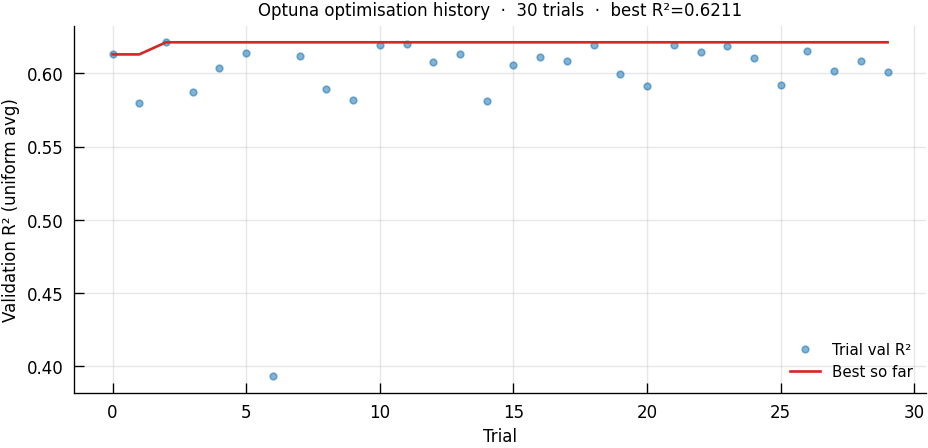

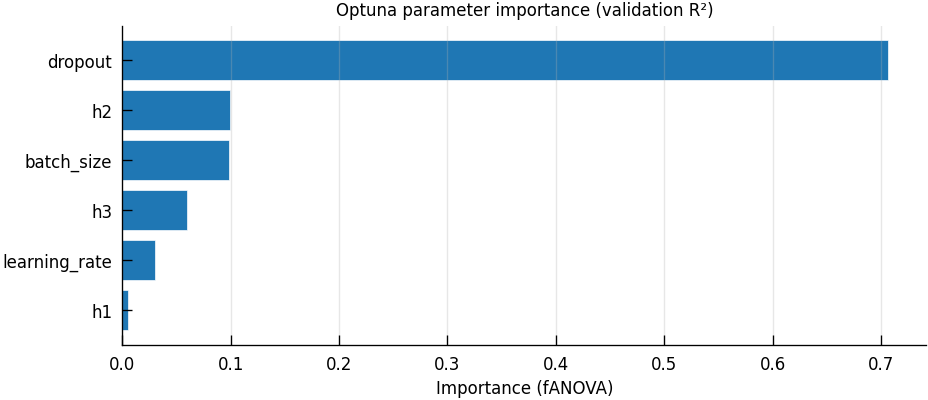

In [8]:
# ════════════════════════════════════════════════════════════════════════════
# 6b. OPTIONAL OPTUNA HYPERPARAMETER TUNING
# ════════════════════════════════════════════════════════════════════════════
# Gated entirely by the IF_HYPERPARAM_TUNING flag (Section 2). When True:
#   1. Carve a validation fold out of the *training* split (test set is left
#      completely untouched).
#   2. Run an Optuna TPE study over h1, h2, h3, dropout, learning_rate,
#      batch_size; the objective is validation R² in physical units.
#   3. Median pruner stops bad trials early.
#   4. Pick the best trial, refit `model` with those hyperparameters and
#      overwrite the notebook-level H1/H2/H3/DROPOUT/LEARNING_RATE/BATCH_SIZE
#      so the rest of the notebook (tensors, training loop, evaluation,
#      export) runs unchanged on the tuned net.
# When False: the cell prints one line and skips. No new dependency is loaded.
#
# Install once:  pip install optuna

best_params       = None
best_val_r2       = None
tuning_study      = None
n_trials_complete = 0

if IF_HYPERPARAM_TUNING:
    try:
        import optuna
        from optuna.exceptions import TrialPruned
    except ImportError as exc:
        raise ImportError(
            "IF_HYPERPARAM_TUNING=True requires Optuna. Install with `pip install optuna`."
        ) from exc

    # ── Validation fold (train -> train' / val); test stays held out ──────────
    rng_idx = np.random.default_rng(RANDOM_STATE)
    n_train = X_train_s.shape[0]
    perm    = rng_idx.permutation(n_train)
    n_val   = int(round(VAL_FRACTION * n_train))
    val_idx = perm[:n_val]
    tr_idx  = perm[n_val:]

    Xtr_t = torch.tensor(X_train_s[tr_idx],  dtype=torch.float32, device=device)
    ytr_t = torch.tensor(y_train_s[tr_idx],  dtype=torch.float32, device=device)
    Xva_t = torch.tensor(X_train_s[val_idx], dtype=torch.float32, device=device)
    yva_physical = y_train_df.values[val_idx]

    # ── Objective: validation R² (physical units, uniform avg across targets) ──
    def _tune_objective(trial):
        h1_t  = trial.suggest_int("h1", 32, 256, step=32)
        h2_t  = trial.suggest_int("h2", 16, 128, step=16)
        h3_t  = trial.suggest_int("h3", 8,  64,  step=8)
        dp_t  = trial.suggest_float("dropout", 0.0, 0.3)
        lr_t  = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
        bs_t  = trial.suggest_categorical("batch_size", [64, 128, 256, 512])

        torch.manual_seed(RANDOM_STATE)
        net = SimpleNN(n_inputs, h1_t, h2_t, h3_t, n_outputs, dropout=dp_t).to(device)
        opt = optim.Adam(net.parameters(), lr=lr_t)
        ds  = TensorDataset(Xtr_t, ytr_t)
        loader = DataLoader(ds, batch_size=min(bs_t, len(ds)), shuffle=True)

        report_every = max(1, EPOCHS_PER_TRIAL // 5)
        for ep in range(EPOCHS_PER_TRIAL):
            net.train()
            for xb, yb in loader:
                opt.zero_grad()
                F.mse_loss(net(xb), yb).backward()
                opt.step()

            if ep % report_every == 0 or ep == EPOCHS_PER_TRIAL - 1:
                net.eval()
                with torch.no_grad():
                    yp_s = net(Xva_t).cpu().numpy()
                yp = scaler_y.inverse_transform(yp_s) if scaler_y is not None else yp_s
                val_r2 = r2_score(yva_physical, yp, multioutput="uniform_average")
                trial.report(val_r2, ep)
                if trial.should_prune():
                    raise TrialPruned()

        return val_r2

    # ── Run study ─────────────────────────────────────────────────────────────
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
    pruner  = optuna.pruners.MedianPruner(n_warmup_steps=2)
    tuning_study = optuna.create_study(
        direction="maximize", sampler=sampler, pruner=pruner,
        study_name="Main_6_SimpleNN_tuning",
    )
    tuning_study.optimize(
        _tune_objective, n_trials=N_TRIALS, timeout=TUNING_TIMEOUT_S,
        show_progress_bar=False,
    )

    completed = [t for t in tuning_study.trials if t.value is not None]
    n_trials_complete = len(completed)
    best_params = tuning_study.best_params
    best_val_r2 = float(tuning_study.best_value)

    print("=" * 70)
    print(f"Optuna tuning finished  ·  {n_trials_complete} completed trials")
    print(f"  Best validation R² (uniform avg, physical units): {best_val_r2:.4f}")
    print(f"  Best params: {best_params}")
    print("=" * 70)

    # ── Adopt the best hyperparameters and rebuild the production model ───────
    H1            = int(best_params.get("h1", H1))
    H2            = int(best_params.get("h2", H2))
    H3            = int(best_params.get("h3", H3))
    DROPOUT       = float(best_params.get("dropout", DROPOUT))
    LEARNING_RATE = float(best_params.get("learning_rate", LEARNING_RATE))
    BATCH_SIZE    = int(best_params.get("batch_size", BATCH_SIZE))

    torch.manual_seed(RANDOM_STATE)
    model = SimpleNN(n_inputs, H1, H2, H3, n_outputs, dropout=DROPOUT).to(device)
    print(f"\nRebuilt model with tuned params:")
    print(f"  arch:  h1={H1}, h2={H2}, h3={H3}, dropout={DROPOUT}")
    print(f"  train: lr={LEARNING_RATE}, batch_size={BATCH_SIZE}")

    # ── Diagnostic plots: optimisation history + parameter importance ─────────
    trial_nums = [t.number for t in completed]
    trial_vals = [t.value  for t in completed]
    best_so_far = np.maximum.accumulate(trial_vals) if trial_vals else []

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(trial_nums, trial_vals, "o", alpha=0.55, color="#1f77b4", label="Trial val R²")
    if len(best_so_far) > 0:
        ax.plot(trial_nums, best_so_far, "-", lw=1.6, color="#d62728", label="Best so far")
    ax.set_xlabel("Trial")
    ax.set_ylabel("Validation R² (uniform avg)")
    ax.set_title(f"Optuna optimisation history  ·  {n_trials_complete} trials"
                 f"  ·  best R²={best_val_r2:.4f}")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="lower right", fontsize=9)
    plt.tight_layout()
    if IF_PLOT_EXPORT:
        FIG_DIR.mkdir(parents=True, exist_ok=True)
        fig.savefig(FIG_DIR / "optuna_optimization_history.png", dpi=150, bbox_inches="tight")
    if IF_PLOT_SHOWN:
        plt.show()
    plt.close(fig)

    try:
        importances = optuna.importance.get_param_importances(tuning_study)
        if importances:
            fig2, ax2 = plt.subplots(figsize=(8, 3.6))
            names = list(importances.keys())
            vals  = list(importances.values())
            ax2.barh(names[::-1], vals[::-1], color="#1f77b4", edgecolor="white", linewidth=0.4)
            ax2.set_xlabel("Importance (fANOVA)")
            ax2.set_title("Optuna parameter importance (validation R²)")
            ax2.grid(True, axis="x", alpha=0.3)
            plt.tight_layout()
            if IF_PLOT_EXPORT:
                fig2.savefig(FIG_DIR / "optuna_param_importance.png", dpi=150, bbox_inches="tight")
            if IF_PLOT_SHOWN:
                plt.show()
            plt.close(fig2)
    except Exception as e:
        print(f"[INFO] Skipping param-importance plot: {e}")

else:
    print("Optuna hyperparameter tuning disabled (IF_HYPERPARAM_TUNING=False).")
    print("Set IF_HYPERPARAM_TUNING=True in Section 2 to enable a TPE search.")

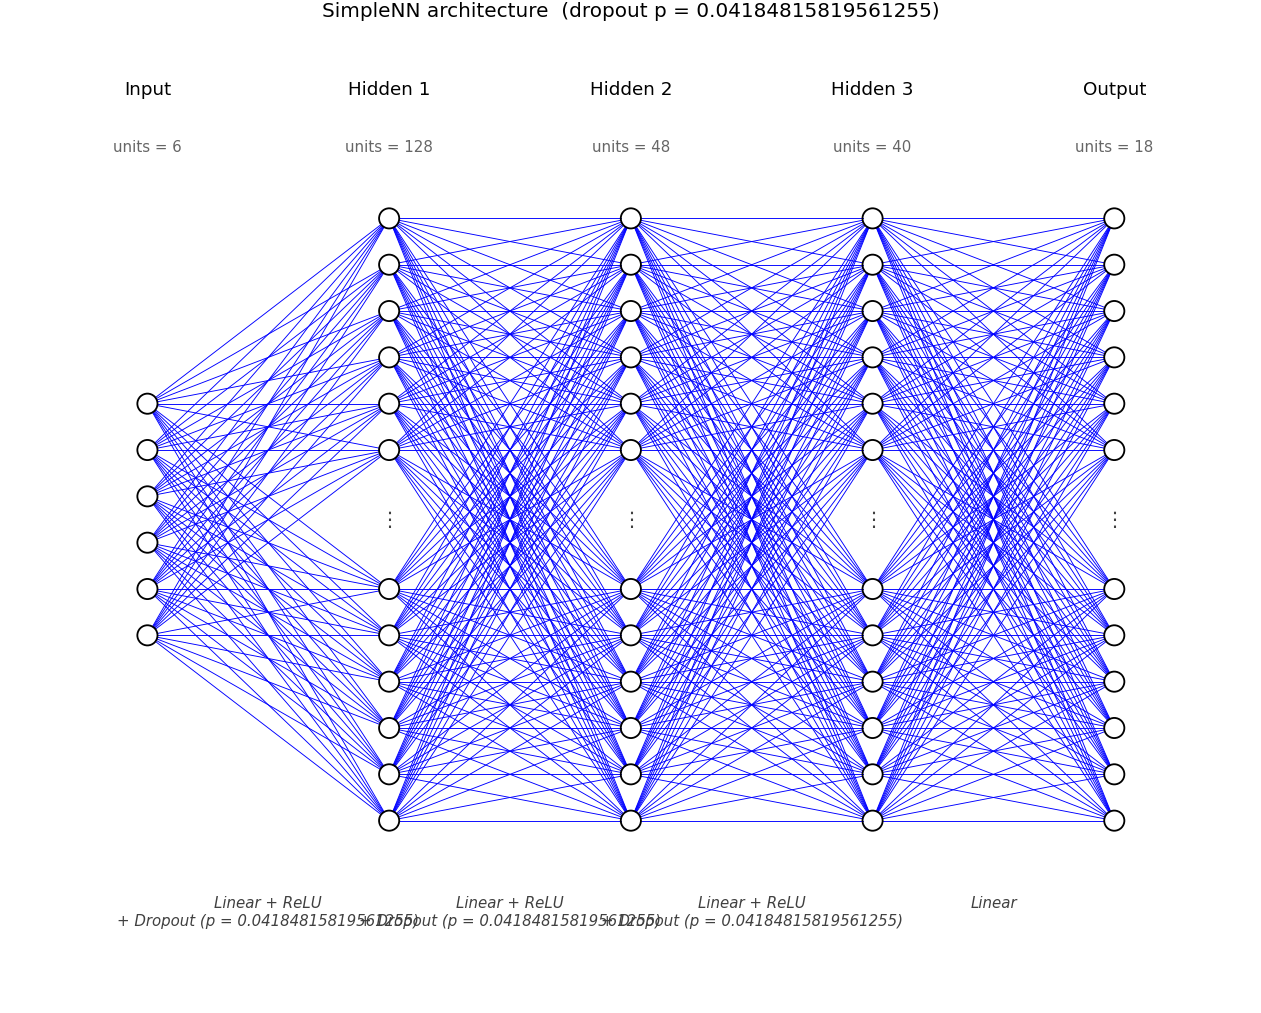

In [9]:
# ════════════════════════════════════════════════════════════════════════════
# 6c. ARCHITECTURE VISUALISATION
# ════════════════════════════════════════════════════════════════════════════
# Three independent toggles (see Section 2 paths/flags cell):
#   IF_ARCH_SUMMARY      → torchinfo textual summary (layer-by-layer shapes/params)
#   IF_ARCH_DIAGRAM_MPL  → matplotlib schematic  (src.utils.draw_mlp_architecture)
#   IF_ARCH_DIAGRAM_TIKZ → standalone TikZ .tex  (src.utils.write_tikz_mlp)
# The diagram renderers live in src/utils/plot_nn_architecture.py so this cell
# only has to describe the network and call them.
from src.utils import draw_mlp_architecture, write_tikz_mlp

layer_sizes = [n_inputs, H1, H2, H3, n_outputs]
layer_names = ['Input', 'Hidden 1', 'Hidden 2', 'Hidden 3', 'Output']
layer_ops   = ['Linear + ReLU + Dropout',
               'Linear + ReLU + Dropout',
               'Linear + ReLU + Dropout',
               'Linear']

# ── (a) torchinfo textual summary ─────────────────────────────────────────────
if IF_ARCH_SUMMARY:
    try:
        from torchinfo import summary as _torchinfo_summary
        print(_torchinfo_summary(
            model, input_size=(1, n_inputs), device=device,
            col_names=("input_size", "output_size", "num_params", "trainable"),
            verbose=0,
        ))
    except ImportError:
        print("[INFO] torchinfo not installed. `pip install torchinfo` for a layer table.")
        print(model)

# ── (b) Matplotlib architecture diagram ──────────────────────────────────────
if IF_ARCH_DIAGRAM_MPL:
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    save_path = FIG_DIR / 'architecture_diagram.png' if IF_PLOT_EXPORT else None
    fig_arch = draw_mlp_architecture(
        layer_sizes, layer_names, layer_ops, DROPOUT,
        save_path=save_path,
    )
    if IF_PLOT_SHOWN:
        plt.show()
    plt.close(fig_arch)

# ── (c) Publication-grade TikZ (.tex) ────────────────────────────────────────
if IF_ARCH_DIAGRAM_TIKZ:
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    tex_path = write_tikz_mlp(
        layer_sizes, layer_names, layer_ops, DROPOUT,
        FIG_DIR / 'architecture_diagram.tex',
    )
    print(f"\nTikZ source written: {tex_path}")
    print("  Compile with:  pdflatex architecture_diagram.tex")

In [10]:
# ════════════════════════════════════════════════════════════════════════════
# 7. TENSORS & DATA LOADERS
# ════════════════════════════════════════════════════════════════════════════
X_train_t = torch.tensor(X_train_s, dtype=torch.float32, device=device)
X_test_t  = torch.tensor(X_test_s,  dtype=torch.float32, device=device)
y_train_t = torch.tensor(y_train_s, dtype=torch.float32, device=device)
y_test_t  = torch.tensor(y_test_s,  dtype=torch.float32, device=device)

train_ds     = TensorDataset(X_train_t, y_train_t)
batch_size   = min(BATCH_SIZE, len(train_ds))
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

print(f"Tensors on device: {device}")
print(f"X_train_t: {tuple(X_train_t.shape)}  |  y_train_t: {tuple(y_train_t.shape)}")
print(f"Batches/epoch: {len(train_loader)}  |  batch_size: {batch_size}")

In [11]:
# ════════════════════════════════════════════════════════════════════════════
# 8. TRAINING LOOP
# ════════════════════════════════════════════════════════════════════════════
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Per-epoch training MSE (standardised target space) and periodic test
# checkpoints with MSE + uniform-average R² in physical units. The R²
# checkpoints are cheap (single forward pass on the full test tensor) and
# give the convergence plot real information instead of just "loss went down".
# This is also the main *overfitting diagnostic* in this notebook: compare
# train vs test curves in §8b (see overview markdown "Overfitting mitigation").
train_loss_log = []
epoch_log      = []
test_loss_log  = []
train_r2_log   = []
test_r2_log    = []

eval_every = max(1, EPOCHS // 40)
log_every  = max(1, EPOCHS // 20)

y_train_true = y_train_df.values
y_test_true  = y_test_df.values

for epoch in range(EPOCHS):
    model.train()
    batch_losses = []
    for xb, yb in train_loader:
        optimizer.zero_grad()
        y_pred = model(xb)
        loss = criterion(y_pred, yb)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())

    mean_train_loss = float(np.mean(batch_losses))
    train_loss_log.append(mean_train_loss)

    if epoch % eval_every == 0 or epoch == EPOCHS - 1:
        model.eval()
        with torch.no_grad():
            y_pred_train_t = model(X_train_t)
            y_pred_test_t  = model(X_test_t)
            test_mse = criterion(y_pred_test_t, y_test_t).item()

            ypt = y_pred_train_t.cpu().numpy()
            yps = y_pred_test_t.cpu().numpy()
            if scaler_y is not None:
                ypt = scaler_y.inverse_transform(ypt)
                yps = scaler_y.inverse_transform(yps)

            tr_r2 = r2_score(y_train_true, ypt, multioutput='uniform_average')
            te_r2 = r2_score(y_test_true,  yps, multioutput='uniform_average')

        epoch_log.append(epoch)
        test_loss_log.append(test_mse)
        train_r2_log.append(tr_r2)
        test_r2_log.append(te_r2)

    if epoch % log_every == 0 or epoch == EPOCHS - 1:
        msg = f"Epoch {epoch:4d}/{EPOCHS} | train MSE: {mean_train_loss:.6f}"
        if test_loss_log:
            msg += f" | test MSE: {test_loss_log[-1]:.6f} | test R²: {test_r2_log[-1]:.4f}"
        print(msg)

print("\nTraining complete.")

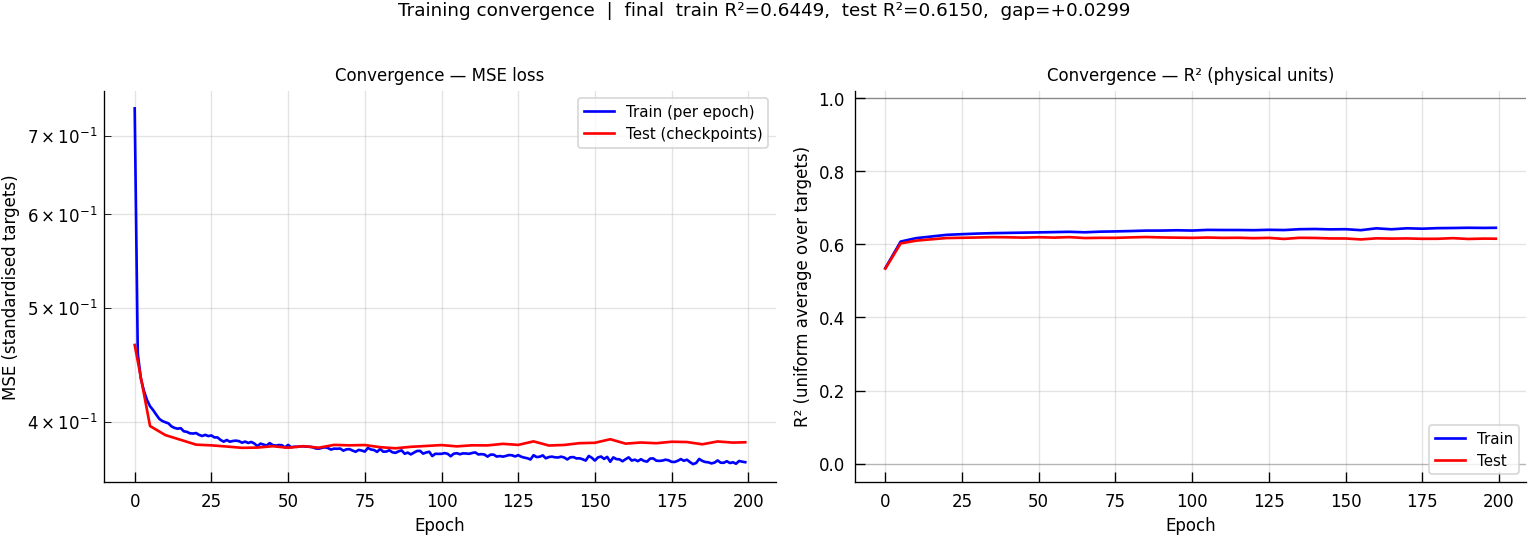

In [12]:
# ════════════════════════════════════════════════════════════════════════════
# 8b. CONVERGENCE — TRAIN/TEST MSE AND R² VS EPOCH
# ════════════════════════════════════════════════════════════════════════════
fig, (ax_loss, ax_r2) = plt.subplots(1, 2, figsize=(13, 4.5))

# ── Panel A: MSE loss vs epoch ────────────────────────────────────────────────
ax_loss.plot(range(len(train_loss_log)), train_loss_log,
             color='b', lw=1.6, label='Train (per epoch)')
ax_loss.plot(epoch_log, test_loss_log,
             color='r', lw=1.6, ls='-', ms=4, label='Test (checkpoints)')
loss_label = 'MSE (standardised targets)' if SCALE_TARGETS else 'MSE'
ax_loss.set_xlabel('Epoch')
ax_loss.set_ylabel(loss_label)
ax_loss.set_yscale('log')
ax_loss.set_title('Convergence — MSE loss')
ax_loss.grid(True, which='both', alpha=0.35)
ax_loss.legend(loc='upper right', frameon=True, fontsize=9)

# ── Panel B: R² vs epoch (physical units, uniform avg) ────────────────────────
ax_r2.plot(epoch_log, train_r2_log,
           color='b', lw=1.6, label='Train')
ax_r2.plot(epoch_log, test_r2_log,
           color='r', lw=1.6, ls='-', label='Test')
ax_r2.axhline(1.0, color='k', lw=0.8, alpha=0.4)
ax_r2.axhline(0.0, color='k', lw=0.8, alpha=0.2)
ax_r2.set_xlabel('Epoch')
ax_r2.set_ylabel('R² (uniform average over targets)')
ax_r2.set_title('Convergence — R² (physical units)')
r2_min = min(min(train_r2_log), min(test_r2_log))
ax_r2.set_ylim(bottom=min(-0.05, r2_min - 0.05), top=1.02)
ax_r2.grid(True, alpha=0.35)
ax_r2.legend(loc='lower right', frameon=True, fontsize=9)

# Final overfit summary as a figure annotation
final_gap = train_r2_log[-1] - test_r2_log[-1]
fig.suptitle(
    f"Training convergence  |  final  train R²={train_r2_log[-1]:.4f},  "
    f"test R²={test_r2_log[-1]:.4f},  gap={final_gap:+.4f}",
    y=1.02, fontsize=11,
)
plt.tight_layout()

if IF_PLOT_EXPORT:
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(FIG_DIR / 'training_convergence.png', dpi=150, bbox_inches='tight')
if IF_PLOT_SHOWN:
    plt.show()
plt.close(fig)

In [13]:
# ════════════════════════════════════════════════════════════════════════════
# 9. TEST-SET EVALUATION
# ════════════════════════════════════════════════════════════════════════════
# Predictions are computed on the standardised tensors then inverse-transformed
# back to physical units (when SCALE_TARGETS is True) before scoring.

model.eval()
with torch.no_grad():
    y_pred_train_s = model(X_train_t).cpu().numpy()
    y_pred_test_s  = model(X_test_t).cpu().numpy()

if scaler_y is not None:
    y_pred_train = scaler_y.inverse_transform(y_pred_train_s)
    y_pred_test  = scaler_y.inverse_transform(y_pred_test_s)
else:
    y_pred_train = y_pred_train_s
    y_pred_test  = y_pred_test_s

y_train_np = y_train_df.values
y_test_np  = y_test_df.values

train_r2 = r2_score(y_train_np, y_pred_train, multioutput='uniform_average')
test_r2  = r2_score(y_test_np,  y_pred_test,  multioutput='uniform_average')
test_mae  = mean_absolute_error(y_test_np, y_pred_test, multioutput='uniform_average')
test_rmse = np.sqrt(mean_squared_error(y_test_np, y_pred_test, multioutput='uniform_average'))

print("=" * 70)
print("PyTorch MLP — Test set summary")
print("=" * 70)
print(f"  Train R² (uniform avg): {train_r2:.4f}")
print(f"  Test  R² (uniform avg): {test_r2:.4f}")
print(f"  Test  MAE              : {test_mae:.4g}")
print(f"  Test  RMSE             : {test_rmse:.4g}")
print(f"  Overfit gap (Train-Test R²): {train_r2 - test_r2:.4f}")
print("=" * 70)

# Per-target table
rows = []
for i, tgt in enumerate(target_cols):
    yt = y_test_np[:, i]
    yp = y_pred_test[:, i]
    mask = np.abs(yt) > 1e-12
    mape = np.mean(np.abs((yt[mask] - yp[mask]) / yt[mask])) * 100 if mask.any() else np.nan
    rows.append({
        'target': tgt,
        'R2':     r2_score(yt, yp),
        'MAE':    mean_absolute_error(yt, yp),
        'RMSE':   np.sqrt(mean_squared_error(yt, yp)),
        'MAPE_%': mape,
    })
df_per_target = pd.DataFrame(rows).sort_values('R2', ascending=False)
print("\nPer-target metrics (top 15 by R²):")
print(df_per_target.head(15).to_string(index=False))

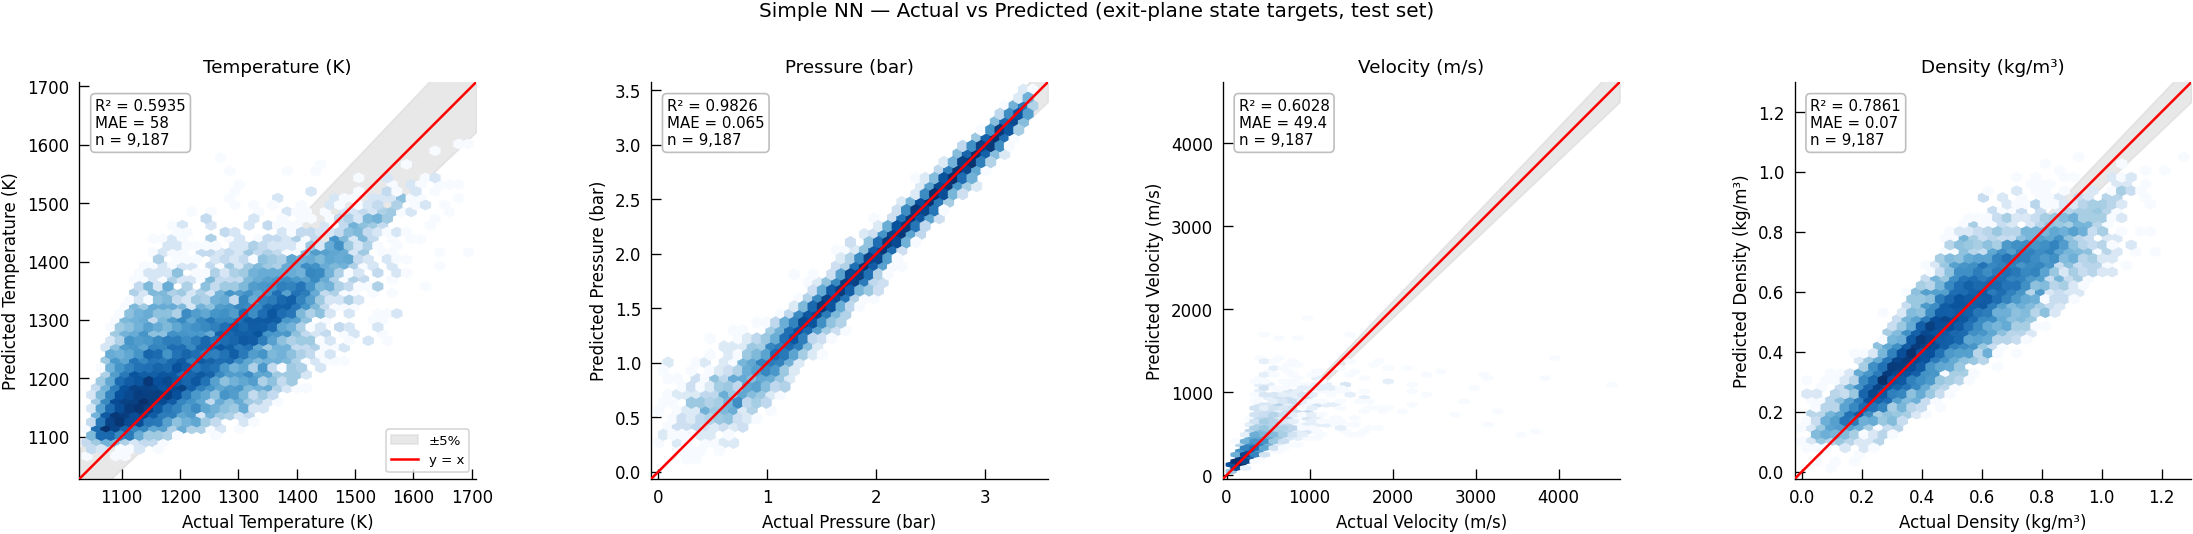

In [14]:
# ════════════════════════════════════════════════════════════════════════════
# 10. ACTUAL VS PREDICTED — STATE VARIABLES
# ════════════════════════════════════════════════════════════════════════════
# Perfect predictions lie on y=x diagonal. Species/lumped targets are left to a
# follow-up notebook; here we focus on the main exit-plane state variables.

STATE_LABELS = {
    'temperature_K':                ('Temperature',          'K',     1.0),
    'pressure_Pa':                  ('Pressure',             'bar',   1e-5),
    'velocity_ms':                  ('Velocity',             'm/s',   1.0),
    'density_kgm3':                 ('Density',              'kg/m³', 1.0),
    'mean_molecular_weight_kgkmol': ('Mean MW',              'kg/kmol', 1.0),
    'heat_capacity_cp_JkgK':        ('Cp',                   'J/(kg·K)', 1.0),
    'heat_capacity_cv_JkgK':        ('Cv',                   'J/(kg·K)', 1.0),
    'enthalpy_Jkg':                 ('Enthalpy',             'J/kg',  1.0),
    'thermal_conductivity_WmK':     ('Thermal conductivity', 'W/(m·K)', 1.0),
}

preferred_state_targets = ['temperature_K', 'pressure_Pa', 'velocity_ms', 'density_kgm3']
scatter_targets = [t for t in preferred_state_targets if t in state_target_cols]
if not scatter_targets:
    scatter_targets = state_target_cols[:4]

def _axis_label(target_name):
    name, unit, _ = STATE_LABELS.get(target_name, (target_name, '', 1.0))
    return f'{name} ({unit})' if unit else name

if scatter_targets:
    n_panels = len(scatter_targets)
    n_cols   = min(4, n_panels)
    n_rows   = (n_panels + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.8 * n_cols, 4.4 * n_rows), squeeze=False)
    flat_axes = axes.ravel()

    for i, tgt in enumerate(scatter_targets):
        ax = flat_axes[i]
        tgt_idx = target_cols.index(tgt)
        _, _, scale = STATE_LABELS.get(tgt, (tgt, '', 1.0))
        yt = y_test_np[:, tgt_idx] * scale
        yp = y_pred_test[:, tgt_idx] * scale

        # Axis limits with a small margin
        lo = float(min(yt.min(), yp.min()))
        hi = float(max(yt.max(), yp.max()))
        pad = 0.02 * (hi - lo if hi > lo else 1.0)
        lims = (lo - pad, hi + pad)

        # ±5% relative-error band (only meaningful when values are strictly > 0)
        if lo > 0:
            x_band = np.linspace(lims[0], lims[1], 200)
            ax.fill_between(x_band, 0.95 * x_band, 1.05 * x_band,
                            color='0.85', alpha=0.6, zorder=0, label='±5%')

        # Density-coloured scatter (2-D histogram on the actual axis range)
        try:
            from matplotlib.colors import LogNorm
            hb = ax.hexbin(yt, yp, gridsize=40, mincnt=1,
                           cmap='Blues', norm=LogNorm(), zorder=2)
        except Exception:
            ax.scatter(yt, yp, alpha=0.3, s=12, edgecolors='none', c='b', zorder=2)

        # 1:1 reference line
        ax.plot(lims, lims, 'r-', lw=1.5, zorder=3, label='y = x')

        ax.set_xlim(lims)
        ax.set_ylim(lims)
        ax.set_aspect('equal', adjustable='box')

        # In-axes metrics box
        r2  = r2_score(yt, yp)
        mae = mean_absolute_error(yt, yp)
        ax.text(0.04, 0.96,
                f'R² = {r2:.4f}\nMAE = {mae:.3g}\nn = {len(yt):,}',
                transform=ax.transAxes, va='top', ha='left', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='0.7', alpha=0.85))

        ax.set_title(_axis_label(tgt), fontsize=11)
        ax.set_xlabel(f'Actual {_axis_label(tgt)}')
        ax.set_ylabel(f'Predicted {_axis_label(tgt)}')

        if i == 0:
            ax.legend(loc='lower right', fontsize=8, frameon=True)

    for j in range(n_panels, len(flat_axes)):
        flat_axes[j].set_visible(False)

    plt.suptitle('Simple NN — Actual vs Predicted (exit-plane state targets, test set)', y=1.02)
    plt.tight_layout()
    if IF_PLOT_EXPORT:
        FIG_DIR.mkdir(parents=True, exist_ok=True)
        fig.savefig(FIG_DIR / 'actual_vs_predicted_state_scatter.png', dpi=150, bbox_inches='tight')
    if IF_PLOT_SHOWN:
        plt.show()
    plt.close(fig)
else:
    print("No state targets available to plot.")

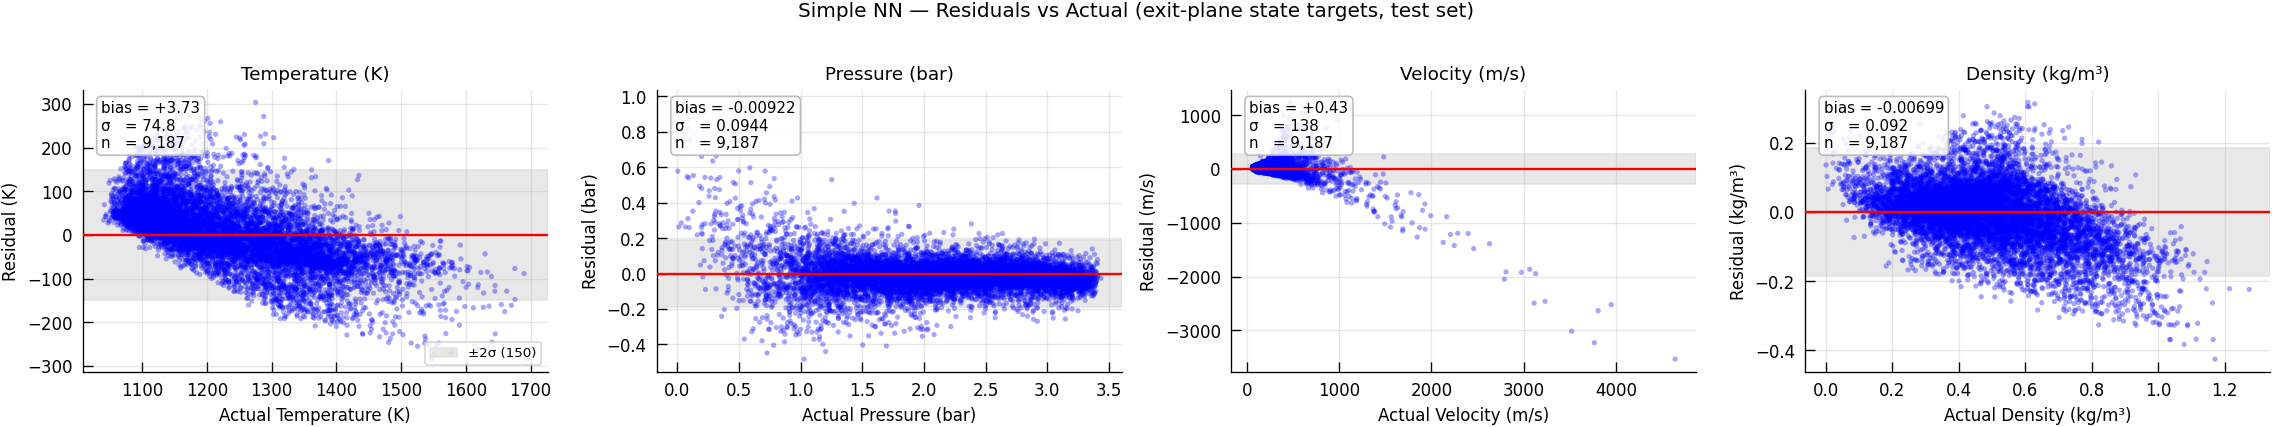

In [15]:
# ════════════════════════════════════════════════════════════════════════════
# 10b. RESIDUALS — STATE VARIABLES
# ════════════════════════════════════════════════════════════════════════════
# Residual = (predicted - actual). Plotting vs. actual exposes systematic bias
# (slope/curvature) and heteroscedasticity (changing spread with magnitude),
# both of which can hide on a parity plot.

if scatter_targets:
    n_panels = len(scatter_targets)
    n_cols   = min(4, n_panels)
    n_rows   = (n_panels + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.8 * n_cols, 3.6 * n_rows), squeeze=False)
    flat_axes = axes.ravel()

    for i, tgt in enumerate(scatter_targets):
        ax = flat_axes[i]
        tgt_idx = target_cols.index(tgt)
        _, _, scale = STATE_LABELS.get(tgt, (tgt, '', 1.0))
        yt   = y_test_np[:, tgt_idx]   * scale
        yp   = y_pred_test[:, tgt_idx] * scale
        res  = yp - yt
        sigma = float(np.std(res))
        bias  = float(np.mean(res))

        ax.axhline(0, color='r', lw=1.4, zorder=3)
        ax.axhspan(-2 * sigma, 2 * sigma, color='0.85', alpha=0.6, zorder=0,
                   label=f'±2σ ({2 * sigma:.3g})')
        ax.scatter(yt, res, alpha=0.35, s=10, edgecolors='none', c='b', zorder=2)

        ax.text(0.04, 0.96,
                f'bias = {bias:+.3g}\nσ   = {sigma:.3g}\nn   = {len(yt):,}',
                transform=ax.transAxes, va='top', ha='left', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='0.7', alpha=0.85))

        unit = STATE_LABELS.get(tgt, (tgt, '', 1.0))[1]
        ax.set_xlabel(f'Actual {_axis_label(tgt)}')
        ax.set_ylabel(f'Residual ({unit})' if unit else 'Residual')
        ax.set_title(_axis_label(tgt), fontsize=11)
        ax.grid(True, alpha=0.3)
        if i == 0:
            ax.legend(loc='lower right', fontsize=8, frameon=True)

    for j in range(n_panels, len(flat_axes)):
        flat_axes[j].set_visible(False)

    plt.suptitle('Simple NN — Residuals vs Actual (exit-plane state targets, test set)', y=1.02)
    plt.tight_layout()
    if IF_PLOT_EXPORT:
        FIG_DIR.mkdir(parents=True, exist_ok=True)
        fig.savefig(FIG_DIR / 'residuals_state_scatter.png', dpi=150, bbox_inches='tight')
    if IF_PLOT_SHOWN:
        plt.show()
    plt.close(fig)
else:
    print("No state targets available to plot residuals for.")

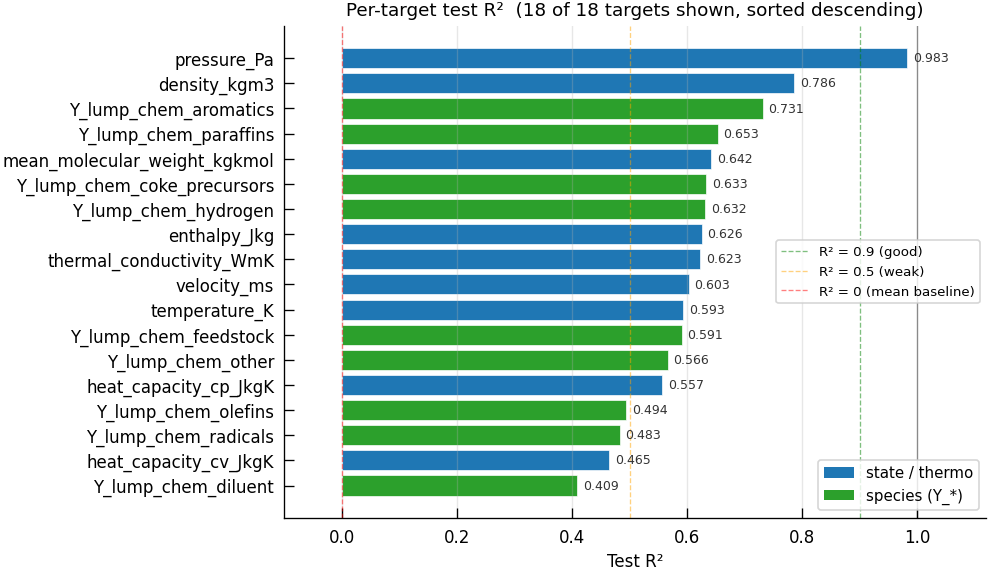

In [16]:
# ════════════════════════════════════════════════════════════════════════════
# 10c. PER-TARGET R² BAR CHART
# ════════════════════════════════════════════════════════════════════════════
# Single-glance scoreboard across every target the network predicts, colour-
# coded by family (state vs species) and sorted descending. R² is clipped to
# [-0.05, 1.0] for plotting so degenerate targets don't compress the scale.

_state_set = set(state_target_cols)
df_bar = df_per_target.copy()
df_bar['family'] = df_bar['target'].apply(lambda t: 'state' if t in _state_set else 'species')
df_bar = df_bar.sort_values('R2', ascending=False).reset_index(drop=True)

# Cap displayed bars to keep the figure readable
MAX_BARS = 40
df_bar_plot = df_bar.head(MAX_BARS).iloc[::-1]  # reverse so highest R² ends up at the top
clipped_r2  = df_bar_plot['R2'].clip(lower=-0.05, upper=1.0)
colours = df_bar_plot['family'].map({'state': '#1f77b4', 'species': '#2ca02c'}).values

fig_h = max(4.0, 0.28 * len(df_bar_plot))
fig, ax = plt.subplots(figsize=(8.5, fig_h))
bars = ax.barh(df_bar_plot['target'], clipped_r2,
               color=colours, edgecolor='white', linewidth=0.4)
ax.axvline(1.0, color='k', lw=0.8, alpha=0.4)
ax.axvline(0.9, color='g', lw=0.8, ls='--', alpha=0.5, label='R² = 0.9 (good)')
ax.axvline(0.5, color='orange', lw=0.8, ls='--', alpha=0.5, label='R² = 0.5 (weak)')
ax.axvline(0.0, color='r', lw=0.8, ls='--', alpha=0.5, label='R² = 0 (mean baseline)')

# Annotate exact R² to the right of each bar
for tgt, r2 in zip(df_bar_plot['target'], df_bar_plot['R2']):
    ax.text(min(max(r2, -0.05), 1.0) + 0.01, tgt, f'{r2:.3f}',
            va='center', ha='left', fontsize=7.5, color='0.2')

ax.set_xlim(-0.1, 1.12)
ax.set_xlabel('Test R²')
ax.set_title(
    f'Per-target test R²  ({len(df_bar_plot)} of {len(df_bar)} targets shown,'
    f' sorted descending)',
    fontsize=11,
)

# Family legend
from matplotlib.patches import Patch
family_legend = [
    Patch(facecolor='#1f77b4', label='state / thermo'),
    Patch(facecolor='#2ca02c', label='species (Y_*)'),
]
leg1 = ax.legend(handles=family_legend, loc='lower right', fontsize=9, frameon=True)
ax.add_artist(leg1)
ax.legend(loc='center right', fontsize=8, frameon=True)

ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()

if IF_PLOT_EXPORT:
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(FIG_DIR / 'per_target_r2_bar.png', dpi=150, bbox_inches='tight')
if IF_PLOT_SHOWN:
    plt.show()
plt.close(fig)

print(f"All targets: {len(df_bar)}  |  shown: {len(df_bar_plot)}  |  "
      f"min R²={df_bar['R2'].min():.4f}  median R²={df_bar['R2'].median():.4f}  "
      f"max R²={df_bar['R2'].max():.4f}")

In [17]:
# ════════════════════════════════════════════════════════════════════════════
# 11. EXPORT MODEL ARTIFACTS
# ════════════════════════════════════════════════════════════════════════════
# state_dict + scalers/encoder + JSON manifest for downstream inference.

if IF_MODEL_EXPORT:
    EXPORT_DIR.mkdir(parents=True, exist_ok=True)
    stem = "simple_nn_exit"
    run_at = datetime.now().isoformat(timespec="seconds")

    state_path    = EXPORT_DIR / f"{stem}_state_dict.pt"
    scalers_path  = EXPORT_DIR / f"{stem}_scalers.joblib"
    manifest_path = EXPORT_DIR / f"{stem}_manifest.json"

    torch.save(model.state_dict(), state_path)
    joblib.dump(
        {"scaler_X": scaler_X, "scaler_y": scaler_y, "label_encoder": label_encoder},
        scalers_path,
    )

    if IF_HYPERPARAM_TUNING:
        tuning_info = {
            "enabled": True,
            "n_trials_completed": int(n_trials_complete),
            "best_val_r2": float(best_val_r2) if best_val_r2 is not None else None,
            "best_params": best_params if best_params is not None else {},
        }
    else:
        tuning_info = {"enabled": False}

    manifest = {
        "model": "SimpleNN",
        "run_at": run_at,
        "architecture": {
            "in_features":  int(n_inputs),
            "h1":           int(H1),
            "h2":           int(H2),
            "h3":           int(H3),
            "dropout":      float(DROPOUT),
            "out_features": int(n_outputs),
        },
        "training": {
            "epochs":        int(EPOCHS),
            "batch_size":    int(batch_size),
            "learning_rate": float(LEARNING_RATE),
            "random_state":  int(RANDOM_STATE),
            "scale_targets": bool(SCALE_TARGETS),
        },
        "inlet_cols":        inlet_cols,
        "state_target_cols": state_target_cols,
        "species_cols":      species_cols,
        "target_cols":       target_cols,
        "data_file":         str(DATA_FILE),
        "metrics": {
            "train_r2":  float(train_r2),
            "test_r2":   float(test_r2),
            "test_mae":  float(test_mae),
            "test_rmse": float(test_rmse),
        },
        "tuning": tuning_info,
    }
    with open(manifest_path, "w") as f:
        json.dump(manifest, f, indent=2)

    print(f"Exported NN: {state_path.name}, {scalers_path.name}, {manifest_path.name}")
else:
    print("Model export disabled.")

---

## Summary

- **Workflow:** inlet design vector → outlet (exit-plane) state + species mass fractions, predicted with a 3-hidden-layer ReLU MLP (dropout between hidden blocks), trained for `EPOCHS` epochs with Adam and `nn.MSELoss` on standardised targets.
- **Overfitting controls:** dropout, held-out test split, scalers fit on train only, shuffled minibatches, and train vs test convergence curves (see overview).
- **Scope:** baseline first, optional Optuna TPE search (Section 6b) over `h1/h2/h3/dropout/learning_rate/batch_size` when `IF_HYPERPARAM_TUNING=True`. Search uses a validation fold (test set held out), median pruning, validation R² objective, then refits the production model on the best hyperparameters before normal training and evaluation.
- **Next steps:** compare these test-set metrics with the tree baselines from [Main_4_train_and_evaluate_tree_models_IO.ipynb](Main_4_train_and_evaluate_tree_models_IO.ipynb); extend in a follow-up notebook with early stopping, Adam weight decay, learning-rate schedules, and the full axial-profile target set.